# Project 3: Barcode & QR Code Scanner
**UIR · Introduction to Computer Vision · Spring 2026**  
ESIN — Big Data & AI

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/barcode-qr-scanner/blob/main/code/notebook.ipynb)

---

## Objective

Detect, localize, and decode **barcodes and QR codes** from images using classical computer vision techniques — no neural networks.

## Pipeline Overview

```
Input Image
  └─ 1. Grayscale conversion
  └─ 2. Gaussian blur          ← Lecture 2: Linear Filtering / Convolution
  └─ 3. Morphological gradient ← Lecture 4: Non-Linear Filtering
  └─ 4. Otsu threshold         ← Lecture 4: Non-Linear Filtering
  └─ 5. Morphological close    ← Lecture 4: Non-Linear Filtering
  └─ 6. Contour analysis       ← Lecture 9: Boundary Detection
  └─ 7. Multi-variant decoding ← Lectures 2 & 4: convolution + adaptive threshold
  └─ Annotated output
```

## Authors
- *[Your Name]* — *[Student ID]*
- *[Teammate 2]* — *[Student ID]*
- *[Teammate 3]* — *[Student ID]*


## 0 · Setup

Install required packages. Run once per environment.


In [1]:
# ── Install dependencies ────────────────────────────────────────────────────
import subprocess, sys

# Install native zbar library (required by pyzbar)
subprocess.run(['apt-get', 'install', '-y', '-q', 'libzbar0'],
               stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

PACKAGES = [
    'opencv-python-headless',
    'pyzbar',
    'Pillow',
    'python-barcode[images]',
    'qrcode[pil]',
]

for pkg in PACKAGES:
    for flags in [[], ['--break-system-packages']]:
        try:
            subprocess.check_call(
                [sys.executable, '-m', 'pip', 'install', pkg, '-q'] + flags,
                stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
            )
            break
        except subprocess.CalledProcessError:
            continue

print('All dependencies installed.')


In [2]:
# ── Imports ─────────────────────────────────────────────────────────────────
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import qrcode
import barcode
from barcode.writer import ImageWriter
from pyzbar import pyzbar
import io, os

print(f'OpenCV  {cv2.__version__}')
print(f'NumPy   {np.__version__}')


OpenCV  4.13.0
NumPy   2.4.3


## 1 · Test Dataset

We generate synthetic test images programmatically:

| File | Content |
|------|--------|
| `qr_test.png` | QR Code — encodes `https://uir.ac.ma` |
| `barcode_test.png` | EAN-13 barcode — value `5901234123457` |
| `combined_test.png` | Both codes side by side |

> See `data/README.txt` for full dataset description.


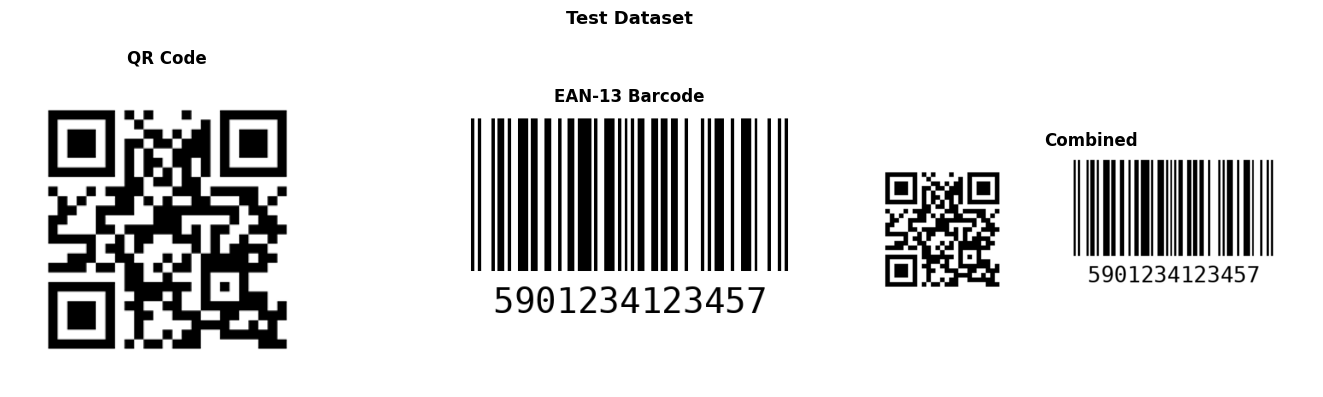

Images saved to data/


In [3]:
# ── Generate synthetic test images ──────────────────────────────────────────

def generate_qr(data: str, size_px: int = 300) -> np.ndarray:
    """
    Generate a QR code image.

    Parameters
    ----------
    data    : str   Content to encode
    size_px : int   Output image size (square)

    Returns
    -------
    np.ndarray  BGR image
    """
    qr = qrcode.QRCode(box_size=6, border=4)
    qr.add_data(data)
    qr.make(fit=True)
    img_pil = qr.make_image(fill_color='black', back_color='white').convert('RGB')
    img_pil = img_pil.resize((size_px, size_px))
    return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)


def generate_barcode_ean13(data: str = '5901234123457') -> np.ndarray:
    """
    Generate an EAN-13 barcode image.

    Parameters
    ----------
    data : str  13-digit EAN code

    Returns
    -------
    np.ndarray  BGR image
    """
    EAN = barcode.get_barcode_class('ean13')
    buf = io.BytesIO()
    EAN(data, writer=ImageWriter()).write(buf)
    buf.seek(0)
    img_pil = Image.open(buf).convert('RGB')
    return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)


# Generate
qr_img  = generate_qr('https://uir.ac.ma')
bar_img = generate_barcode_ean13('5901234123457')

# Side-by-side composite
h = 300
def resize_h(img, h):
    s = h / img.shape[0]
    return cv2.resize(img, (int(img.shape[1] * s), h))

sep     = np.ones((h, 30, 3), dtype=np.uint8) * 255
combined = np.hstack([resize_h(qr_img, h), sep, resize_h(bar_img, h)])

# Save
os.makedirs('../data', exist_ok=True)
cv2.imwrite('../data/qr_test.png',       qr_img)
cv2.imwrite('../data/barcode_test.png',  bar_img)
cv2.imwrite('../data/combined_test.png', combined)

# Display
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, img, title in zip(axes,
                           [qr_img, bar_img, combined],
                           ['QR Code', 'EAN-13 Barcode', 'Combined']):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontweight='bold')
    ax.axis('off')
plt.suptitle('Test Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Images saved to data/')


## 2 · Step 1–2: Grayscale Conversion & Gaussian Blur

**Course reference — Lecture 2: Linear Filtering**

### Grayscale
An image is represented as a 3D tensor $I \in \mathbb{R}^{H \times W \times 3}$ (BGR channels).  
We convert to a single-channel grayscale image using the standard luminance formula:

$$I_{gray} = 0.114 \cdot B + 0.587 \cdot G + 0.299 \cdot R$$

Color information is irrelevant for detecting the bar/edge structure of codes.

### Gaussian Blur
We convolve the grayscale image with a 2D Gaussian kernel to suppress high-frequency noise **before** computing gradients:

$$G_{\sigma}(x, y) = \frac{1}{2\pi\sigma^2} \, e^{-\frac{x^2 + y^2}{2\sigma^2}}$$

$$I_{smooth} = I_{gray} * G_{\sigma}$$

Without this step, noise would produce false edges that corrupt the morphological pipeline.


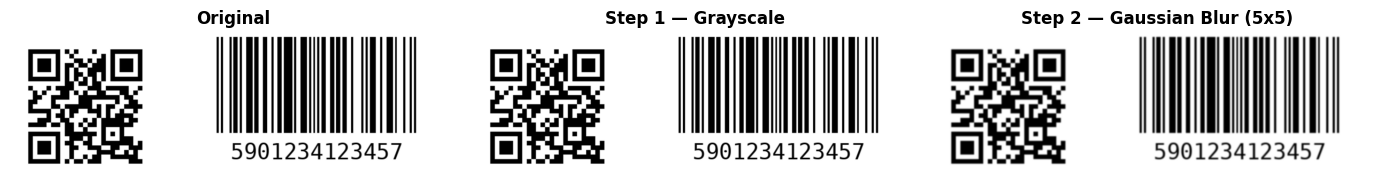

In [4]:
# ── Step 1: Grayscale conversion ────────────────────────────────────────────

def to_gray(img: np.ndarray) -> np.ndarray:
    """
    Convert BGR image to grayscale.

    Parameters
    ----------
    img : np.ndarray  BGR image (H, W, 3)

    Returns
    -------
    np.ndarray  Grayscale image (H, W)
    """
    if len(img.shape) == 2:
        return img
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


# ── Step 2: Gaussian blur ────────────────────────────────────────────────────

def gaussian_blur(gray: np.ndarray, ksize: int = 5) -> np.ndarray:
    """
    Apply Gaussian blur via 2D convolution.
    Kernel size ksize x ksize, sigma computed automatically by OpenCV.

    Parameters
    ----------
    gray  : np.ndarray  Grayscale image
    ksize : int         Kernel size (must be odd)

    Returns
    -------
    np.ndarray  Blurred image
    """
    return cv2.GaussianBlur(gray, (ksize, ksize), 0)


# Apply & visualize
gray    = to_gray(combined)
blurred = gaussian_blur(gray, ksize=5)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original', fontweight='bold')
axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Step 1 — Grayscale', fontweight='bold')
axes[2].imshow(blurred, cmap='gray')
axes[2].set_title('Step 2 — Gaussian Blur (5x5)', fontweight='bold')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()


## 3 · Steps 3–5: Morphological Pipeline

**Course reference — Lecture 4: Non-Linear Filtering**

### Step 3 — Morphological Gradient

A morphological gradient is defined as:

$$\text{gradient}(I, K) = \text{dilate}(I, K) - \text{erode}(I, K)$$

**Dilation** expands bright regions; **erosion** shrinks them.  
Their difference produces an edge-like response — similar in spirit to a gradient operator, but more robust to noise.

We use a **wide rectangular structuring element** $K \in \mathbb{R}^{9 \times 3}$:  
wider horizontally than vertically, to specifically emphasize the **vertical bar transitions** that characterize 1D barcodes.

### Step 4 — Otsu Thresholding

Otsu's method automatically finds the optimal global threshold $t^*$ by **minimizing intra-class variance** between foreground and background pixels:

$$t^* = \arg\min_t \; \omega_0(t)\,\sigma_0^2(t) + \omega_1(t)\,\sigma_1^2(t)$$

No manual threshold tuning needed — the algorithm adapts to each image's histogram.

### Step 5 — Morphological Close

Closing = dilation followed by erosion with the same kernel:

$$\text{close}(I, K) = \text{erode}(\text{dilate}(I, K),\, K)$$

With a wide kernel $(21 \times 7)$, this **bridges the gaps** between individual barcode bars, merging them into a single solid rectangular blob — making contour detection reliable.


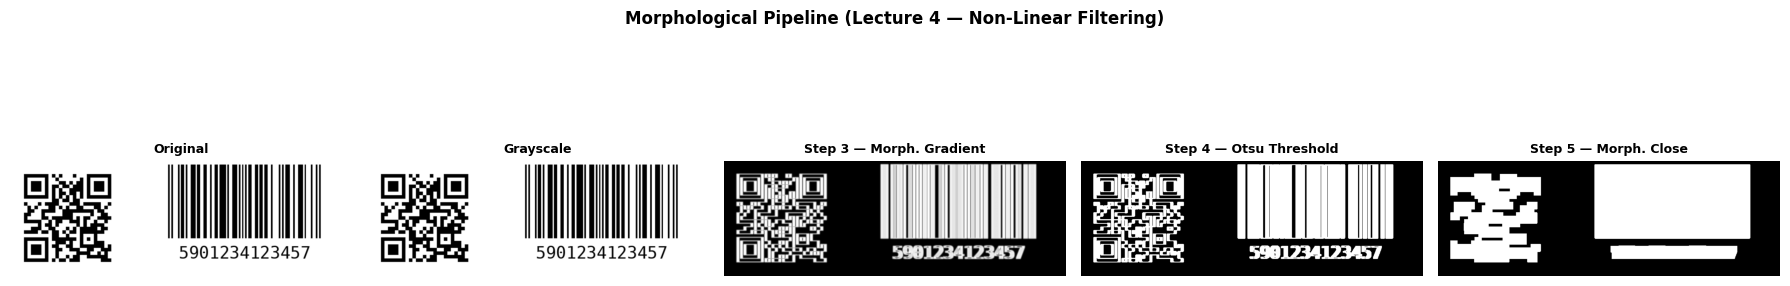

In [5]:
# ── Step 3: Morphological gradient ─────────────────────────────────────────

def morphological_gradient(blurred: np.ndarray) -> np.ndarray:
    """
    Compute morphological gradient = dilate - erode.
    Emphasizes bar-pattern edges in barcodes.

    Parameters
    ----------
    blurred : np.ndarray  Gaussian-blurred grayscale image

    Returns
    -------
    np.ndarray  Gradient image
    """
    kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 3))
    dilated = cv2.dilate(blurred, kernel)
    eroded  = cv2.erode(blurred, kernel)
    return cv2.subtract(dilated, eroded)


# ── Step 4: Otsu binarization ────────────────────────────────────────────────

def otsu_threshold(gradient: np.ndarray) -> np.ndarray:
    """
    Binarize using Otsu's automatic threshold selection.

    Parameters
    ----------
    gradient : np.ndarray  Morphological gradient image

    Returns
    -------
    np.ndarray  Binary image (0 or 255)
    """
    _, binary = cv2.threshold(gradient, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    return binary


# ── Step 5: Morphological close ──────────────────────────────────────────────

def morphological_close(binary: np.ndarray) -> np.ndarray:
    """
    Connect barcode bars into solid blobs via morphological closing.
    Wide horizontal kernel bridges inter-bar gaps.

    Parameters
    ----------
    binary : np.ndarray  Otsu-thresholded binary image

    Returns
    -------
    np.ndarray  Cleaned binary mask
    """
    k_close = cv2.getStructuringElement(cv2.MORPH_RECT, (21, 7))
    closed  = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, k_close)
    k_small = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    cleaned = cv2.erode(closed,  k_small, iterations=4)
    cleaned = cv2.dilate(cleaned, k_small, iterations=4)
    return cleaned


# Apply
gradient = morphological_gradient(blurred)
binary   = otsu_threshold(gradient)
closed   = morphological_close(binary)

# Visualize all steps
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
imgs   = [cv2.cvtColor(combined, cv2.COLOR_BGR2RGB), gray, gradient, binary, closed]
titles = ['Original', 'Grayscale', 'Step 3 — Morph. Gradient',
          'Step 4 — Otsu Threshold', 'Step 5 — Morph. Close']
cmaps  = [None, 'gray', 'gray', 'gray', 'gray']
for ax, img, title, cmap in zip(axes, imgs, titles, cmaps):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.axis('off')
plt.suptitle('Morphological Pipeline (Lecture 4 — Non-Linear Filtering)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 4 · Step 6: Contour Analysis — Localization

**Course reference — Lecture 9: Boundary Detection**

After morphological closing, each barcode/QR region appears as a **solid white blob** in the binary mask.

We extract contours using `cv2.findContours` with:
- `RETR_EXTERNAL` — retrieve only outermost contour boundaries
- `CHAIN_APPROX_SIMPLE` — compressed representation (stores only endpoints)

For each contour $C_i$ we compute:
- $\text{area}(C_i) = $ `cv2.contourArea` — filter noise (threshold: $< 1500$ px²)
- $\text{bbox}(C_i) = (x, y, w, h)$ — axis-aligned bounding rectangle

This gives us **candidate regions** to highlight and pass to the decoder.


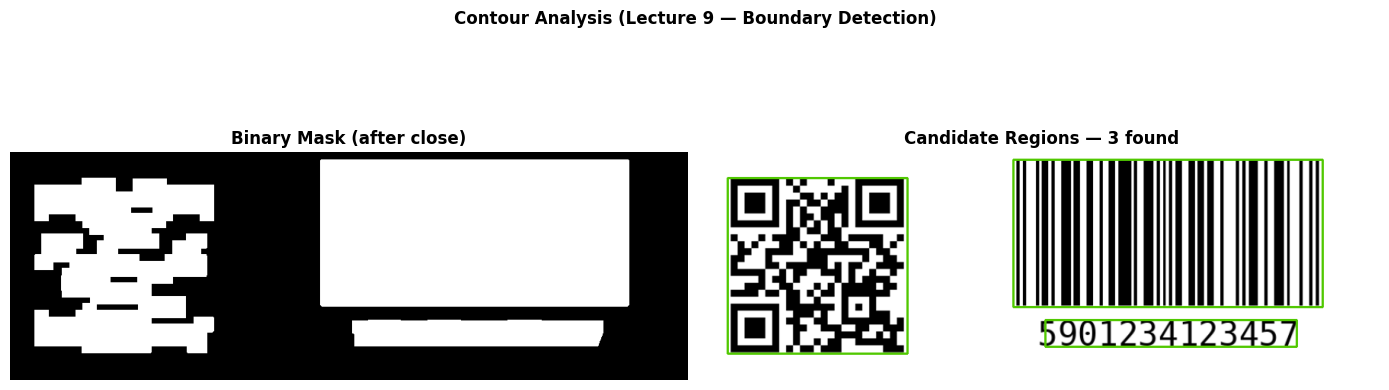

Detected regions: [(449, 221, 330, 35), (32, 35, 236, 230), (407, 11, 406, 193)]


In [6]:
# ── Step 6: Contour analysis — candidate region localization ─────────────────

def find_candidate_regions(mask: np.ndarray, min_area: int = 1500):
    """
    Extract bounding rectangles from contours in binary mask.

    Parameters
    ----------
    mask     : np.ndarray  Binary image (output of morphological close)
    min_area : int         Minimum contour area to accept

    Returns
    -------
    list of (x, y, w, h)
    """
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    regions = []
    for c in contours:
        if cv2.contourArea(c) >= min_area:
            regions.append(cv2.boundingRect(c))
    return regions


regions = find_candidate_regions(closed)

# Draw on original
vis = combined.copy()
for (x, y, w, h) in regions:
    cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 200, 80), 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(closed, cmap='gray')
axes[0].set_title('Binary Mask (after close)', fontweight='bold')
axes[1].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Candidate Regions — {len(regions)} found', fontweight='bold')
for ax in axes: ax.axis('off')
plt.suptitle('Contour Analysis (Lecture 9 — Boundary Detection)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Detected regions: {regions}')


## 5 · Step 7: Multi-Variant Decoding

**Course reference — Lectures 2 & 4: Linear Filtering + Non-Linear Filtering**

We use **pyzbar** (wrapper around the zbar library) to decode barcodes and QR codes.

To maximize the decode rate under real-world conditions (glare, shadows, low contrast), we attempt decoding on **5 preprocessed variants** of the image:

| Variant | Technique | Course concept |
|---------|-----------|----------------|
| Raw BGR | — | — |
| Grayscale | Luminance conversion | Lecture 2 — Image representation |
| Adaptive threshold | Local neighborhood thresholding | Lecture 4 — Non-linear filtering |
| Inverted adaptive | Bitwise NOT | — |
| Sharpened | 2D convolution with sharpening kernel | Lecture 2 — Linear filtering |

Results are **deduplicated** by `(data, type)` pair to avoid repeated detections.

### Sharpening kernel (Lecture 2)
$$K_{sharp} = \begin{bmatrix} 0 & -1 & 0 \\ -1 & 5 & -1 \\ 0 & -1 & 0 \end{bmatrix}$$

This is a **linear filter** applied via 2D convolution — it amplifies the center pixel relative to its neighbors, enhancing edges and fine details.
Equivalent to: $I_{sharp} = I * K_{sharp}$


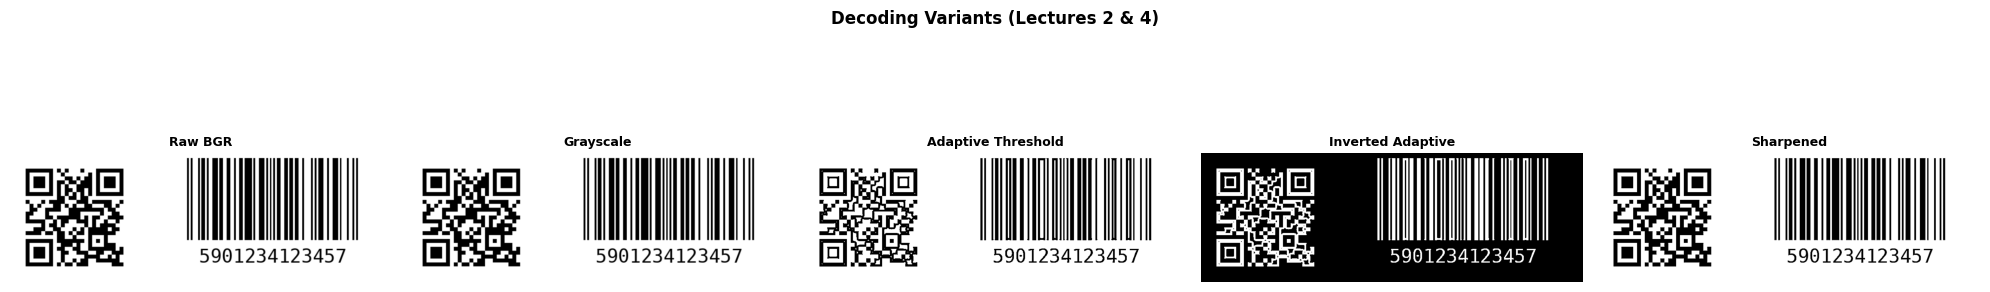

In [7]:
# ── Step 7: Multi-variant decoding ──────────────────────────────────────────

def decode_variants(img_bgr: np.ndarray) -> list:
    """
    Attempt pyzbar decoding on multiple preprocessed image variants.
    Tries: raw, grayscale, adaptive threshold, inverted, sharpened.
    Deduplicates results by (data, type).

    Parameters
    ----------
    img_bgr : np.ndarray  Input BGR image

    Returns
    -------
    list of pyzbar decoded objects
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY) if len(img_bgr.shape) == 3 else img_bgr

    # Adaptive threshold (handles uneven lighting)
    adaptive = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
    )

    # Sharpening via 2D convolution (Lecture 2 — Linear Filtering)
    K_sharp   = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
    sharpened = cv2.filter2D(gray, -1, K_sharp)

    variants = [
        img_bgr,
        gray,
        adaptive,
        cv2.bitwise_not(adaptive),
        sharpened,
    ]

    seen, results = set(), []
    for v in variants:
        for d in pyzbar.decode(v):
            key = (d.data, d.type)
            if key not in seen:
                seen.add(key)
                results.append(d)
    return results


# Visualize the 5 variants
gray_v    = to_gray(combined)
adaptive  = cv2.adaptiveThreshold(gray_v, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
K_sharp   = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32)
sharpened = cv2.filter2D(gray_v, -1, K_sharp)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
variant_imgs   = [combined, gray_v, adaptive, cv2.bitwise_not(adaptive), sharpened]
variant_titles = ['Raw BGR', 'Grayscale', 'Adaptive Threshold', 'Inverted Adaptive', 'Sharpened']
variant_cmaps  = [None, 'gray', 'gray', 'gray', 'gray']
for ax, img, title, cmap in zip(axes, variant_imgs, variant_titles, variant_cmaps):
    disp = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if cmap is None else img
    ax.imshow(disp, cmap=cmap)
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.axis('off')
plt.suptitle('Decoding Variants (Lectures 2 & 4)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 6 · Annotation

Draw detection results on the image:
- **Green polygon** = QR code boundary
- **Blue bounding box** = 1D barcode boundary
- **Label** = code type + decoded data


In [8]:
# ── Annotation ───────────────────────────────────────────────────────────────

def annotate(img_bgr: np.ndarray, decoded_list: list) -> np.ndarray:
    """
    Draw bounding polygons and decoded text labels on image.

    QR codes  → green
    Barcodes  → blue

    Parameters
    ----------
    img_bgr      : np.ndarray  Input BGR image
    decoded_list : list        pyzbar decoded objects

    Returns
    -------
    np.ndarray  Annotated BGR image
    """
    out = img_bgr.copy()
    COLOR_QR  = (0, 200, 100)
    COLOR_BAR = (0, 120, 255)

    for d in decoded_list:
        is_qr = 'QR' in str(d.type).upper()
        color = COLOR_QR if is_qr else COLOR_BAR

        # Polygon outline
        pts = np.array([(p.x, p.y) for p in d.polygon], dtype=np.int32)
        cv2.polylines(out, [pts.reshape(-1, 1, 2)], True, color, 2)

        # Label
        data_str = d.data.decode('utf-8', errors='replace')
        label = f'{d.type}: {data_str[:50]}'
        x, y  = d.rect.left, d.rect.top
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
        ty = max(y - 8, th + 4)
        cv2.rectangle(out, (x, ty - th - 4), (x + tw + 4, ty + 2), (20, 20, 20), -1)
        cv2.putText(out, label, (x + 2, ty), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 1, cv2.LINE_AA)

    return out


## 7 · Full Pipeline

Assemble all steps into a single `scan()` function and run on all test images.


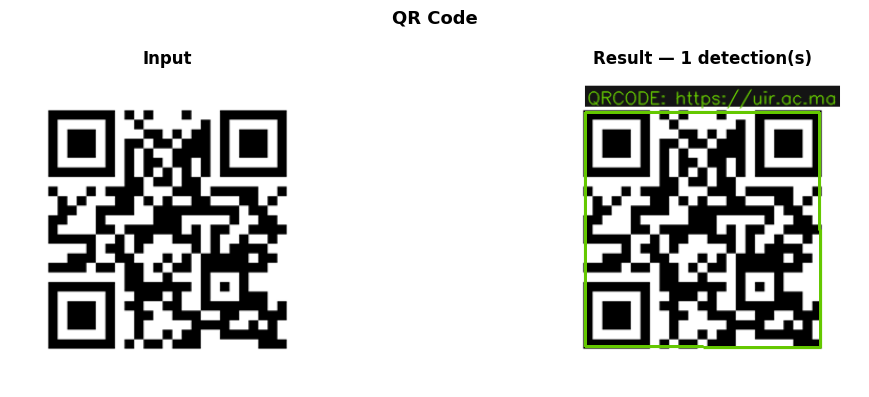

QR Code:
  [QRCODE]  https://uir.ac.ma



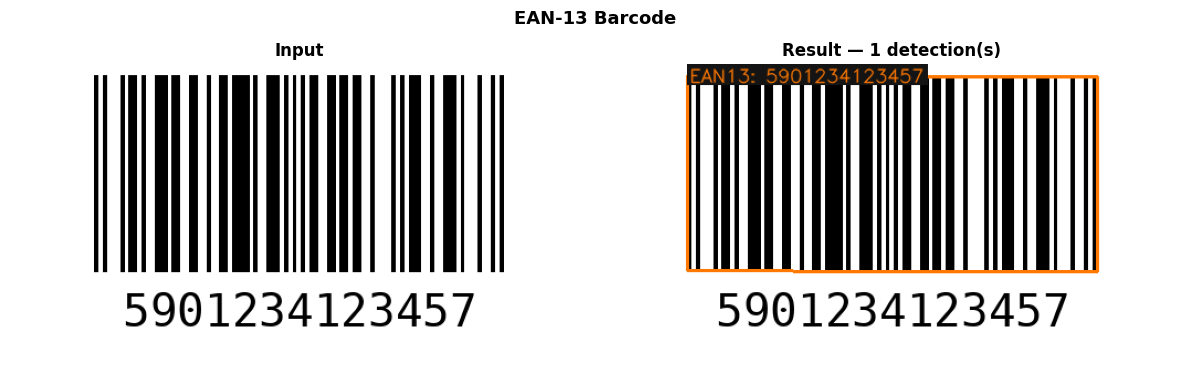

EAN-13 Barcode:
  [EAN13]  5901234123457



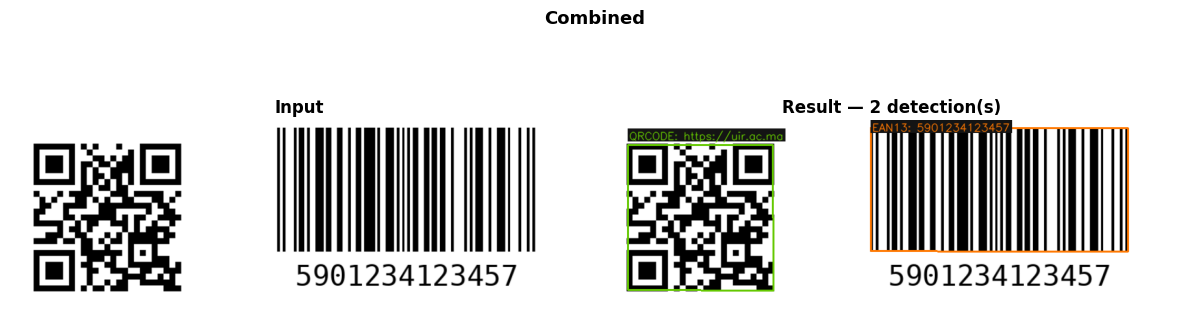

Combined:
  [QRCODE]  https://uir.ac.ma
  [EAN13]  5901234123457



In [9]:
# ── Full end-to-end pipeline ─────────────────────────────────────────────────

def scan(img_bgr: np.ndarray) -> dict:
    """
    Full barcode/QR detection, localization, and decoding pipeline.

    Parameters
    ----------
    img_bgr : np.ndarray  Input BGR image

    Returns
    -------
    dict with keys:
        'detections' : list of decoded objects
        'annotated'  : np.ndarray annotated BGR image
        'steps'      : dict of intermediate images
    """
    # Preprocessing
    gray     = to_gray(img_bgr)
    blurred  = gaussian_blur(gray)
    gradient = morphological_gradient(blurred)
    binary   = otsu_threshold(gradient)
    closed   = morphological_close(binary)

    # Localization
    regions  = find_candidate_regions(closed)

    # Decode
    decoded  = decode_variants(img_bgr)

    # Annotate
    annotated = annotate(img_bgr, decoded)

    return {
        'detections': decoded,
        'annotated' : annotated,
        'steps'     : {
            'gray': gray, 'blurred': blurred,
            'gradient': gradient, 'binary': binary, 'closed': closed
        }
    }


# ── Run on all test images ───────────────────────────────────────────────────
test_images = [
    ('QR Code',       qr_img),
    ('EAN-13 Barcode', bar_img),
    ('Combined',       combined),
]

for name, img in test_images:
    result = scan(img)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Input', fontweight='bold')
    axes[1].imshow(cv2.cvtColor(result['annotated'], cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Result — {len(result['detections'])} detection(s)", fontweight='bold')
    for ax in axes: ax.axis('off')
    plt.suptitle(name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f'{name}:')
    for d in result['detections']:
        print(f'  [{d.type}]  {d.data.decode("utf-8", errors="replace")}')
    print()


## 8 · Interactive Demo — Upload Your Own Image

Upload any image containing barcodes or QR codes.  
The full pipeline runs automatically and displays the result.


In [10]:
# ── Interactive widget ───────────────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, clear_output

uploader   = widgets.FileUpload(accept='image/*', multiple=False, description='Upload Image')
btn_scan   = widgets.Button(description='Scan', button_style='success')
out_widget = widgets.Output()

def on_scan(b):
    with out_widget:
        clear_output(wait=True)
        if not uploader.value:
            print('No image uploaded.')
            return

        # Handle both old and new ipywidgets FileUpload API
        val = uploader.value
        if isinstance(val, dict):
            # ipywidgets < 8: dict keyed by filename
            raw = list(val.values())[0]
            file_content = raw['content'] if isinstance(raw, dict) else bytes(raw)
        else:
            # ipywidgets >= 8: tuple/list of dicts with 'content' key
            raw = val[0] if isinstance(val, (list, tuple)) else val
            file_content = bytes(raw['content'])

        buf = io.BytesIO(file_content)
        buf.seek(0)
        pil_img = Image.open(buf).convert('RGB')
        img_bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

        result = scan(img_bgr)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].imshow(pil_img)
        axes[0].set_title('Input', fontweight='bold')
        axes[1].imshow(cv2.cvtColor(result['annotated'], cv2.COLOR_BGR2RGB))
        axes[1].set_title(f"{len(result['detections'])} detection(s)", fontweight='bold')
        for ax in axes: ax.axis('off')
        plt.tight_layout()
        plt.show()

        if result['detections']:
            for d in result['detections']:
                print(f"[{d.type}]  {d.data.decode('utf-8', errors='replace')}")
        else:
            print('No barcodes or QR codes detected.')

btn_scan.on_click(on_scan)
display(widgets.VBox([uploader, btn_scan, out_widget]))
